Stage 0: Generating waveform...
  Raw output: dtype=complex128, length=659369, duration=76.3 days
Stage 0.5: Extracting TDI channels...
  A channel peak: 4.852e-21
  E channel peak: 4.999e-21
  E/A peak ratio: 1.030
Stage 1: WDM transform (A+E combined)...
  WDM band shape: (255, 512)
  Freq bin width: 38.70 μHz
Stage 2a: WDM t=0 spectrum — Viterbi seed...
  WDM 2fΦ seed:  2.7584 mHz  (true 2fΦ: 2.7700 mHz, err: -0.42%)
Stage 2b: Multi-window fR — 3x3-day windows, extrapolate to t=0...
  Window 1 (t=1.5d): 0.82294 mHz  (true: 0.82292, err: 0.0025%)
  Window 2 (t=4.5d): 0.82806 mHz  (true: 0.82812, err: -0.0071%)
  Window 3 (t=7.5d): 0.83339 mHz  (true: 0.83340, err: -0.0023%)
  Extrapolated fR(t=0): 0.82030 mHz  (true: 0.82036, err: -0.0074%)
  fPhi (10d window): 1.33565 mHz  (true: 1.38500, err: -3.5632%)  [diagnostic]
  ftheta (10d window): 1.31956 mHz  (true: 1.31985, err: -0.0219%)  [diagnostic]


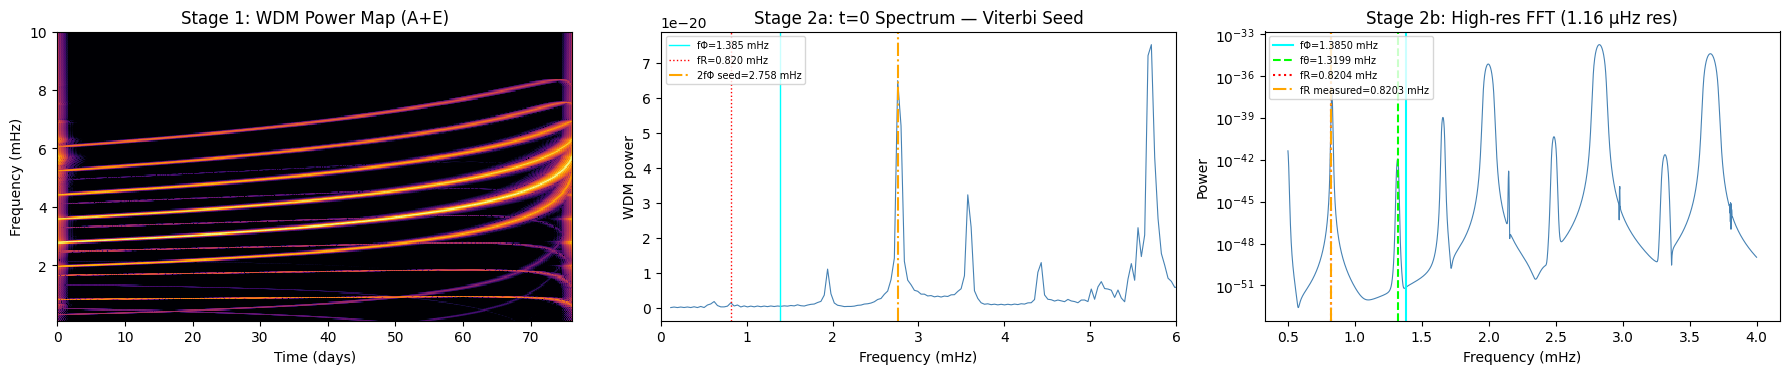

Stage 3: Viterbi track extraction...
  Extracted 512 points
  2fΦ start: 2.7584 mHz  (true: 2.7700 mHz, err: -0.420%)
Stage 4: Extracting fΦ(t)...
  fΦ at t=0: extracted=1.37430 mHz  (true: 1.38500 mHz, err: -0.7727%)
  [Using Viterbi fΦ₀ for e0 recovery — avoids fΦ/fθ confusion]


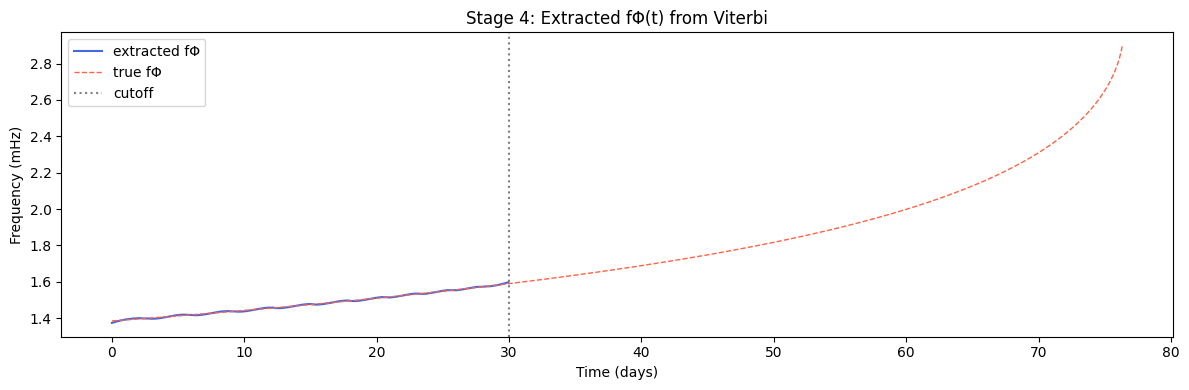

Stage 5: Recovering M and a (trajectory-assisted, high-res fR)...
  M: 1114562.03  (true: 1134944.87, err: -1.796%)
  a: 0.487309  (true: 0.500000, err: -2.538%)
Stage 6: Recovering mu (trajectory-assisted)...
  mu: 30.6325  (true: 29.4900, err: 3.874%)
Stage 7: Blind e0 recovery...
  Blind e0: 0.22866  (true: 0.22866, err: -0.0000%)
Stage 8: Blind M, a, mu recovery...
  M: 1114562.03  (true: 1134944.87, err: -1.796%)
  a: 0.487309  (true: 0.500000, err: -2.538%)
  mu: 30.6325  (true: 29.4900, err: 3.874%)

FINAL RESULTS — Trajectory-assisted vs Fully Blind
Parameter          True  Traj-assist      Err  Fully blind      Err
-----------------------------------------------------------------
M (M☉)        1134944.9    1114562.0  -1.796%    1114562.0  -1.796%
a                0.5000       0.4873  -2.538%       0.4873  -2.538%
mu (M☉)         29.4900      30.6325   3.874%      30.6325   3.874%
e0              0.22866  (traj used)      ---      0.22866 -0.0000%

Key measurements:
  fR:  0.82

In [22]:
# ============================================================
# BLIND EMRI PARAMETER ESTIMATION PIPELINE — KERR
# ============================================================
# Stages:
#   0:   Waveform generation (FEW)
#   0.5: TDI channel extraction (A, E)
#   1:   WDM time-frequency transform (A+E combined power)
#   2:   Frequency identification
#          2a — WDM t=0 spectrum  → 2fΦ seed for Viterbi
#          2b — High-res FFT      → precise fR₀ (and diagnostics)
#   3:   Viterbi track extraction
#   4:   Fundamental frequency extraction fΦ(t)
#   5:   Spacetime parameter recovery (M, a) — trajectory-assisted
#   6:   Secondary mass recovery (mu)  — trajectory-assisted
#   ---- BLIND PATH ----
#   7:   Blind e0 recovery (Viterbi fΦ₀ + high-res fR)
#   8:   Blind M, a, mu recovery
# ============================================================

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import brentq, minimize, curve_fit
from scipy.interpolate import interp1d
import sys, io
_stdout = sys.stdout
sys.stdout = io.StringIO()
from WDMWaveletTransforms.wavelet_transforms import transform_wavelet_time
sys.stdout = _stdout
from few.waveform import GenerateEMRIWaveform
from few.trajectory.inspiral import EMRIInspiral, get_fundamental_frequencies, MTSUN_SI
from few.utils.geodesic import get_separatrix
from few.trajectory.ode.pn5 import PN5

# ============================================================
# STAGE 0 — Waveform Generation
# ============================================================
print("Stage 0: Generating waveform...")

G    = 6.674080e-11
c    = 299792458.
MSUN = 1.98848e30

def Keplerian_p_from_f(M, mu, f_orb_0, e0):
    return c**2 * (1 - e0**2) / (2*np.pi*f_orb_0*G*(M+mu)*MSUN)**(2/3)

M             = 1134944.869275098
m             = 29.489999547765798
f1_measured   = 0.001380463140752472
e0            = 0.22865665220266215
a             = 0.5
p0            = Keplerian_p_from_f(M, m, f1_measured, e0)
Y0            = 1.0
Phi_phi0, Phi_theta0, Phi_r0 = 0., 1.2, 3.5
qS, phiS, qK, phiK = 0.2, 0.2, 0.8, 0.8
dist          = 5.235888314207546
dt            = 10.0
T             = 1

wave_gen = GenerateEMRIWaveform('Pn5AAKWaveform')
traj     = EMRIInspiral(func='PN5')

t, p, e, x, _, _, _ = traj(
    M, m, a, p0, e0, Y0,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0,
    dt=dt, T=T, upsample=True, fix_t=True)

h_full = wave_gen(
    M, m, a, p0, e0, Y0,
    qS, phiS, qK, phiK, dist,
    Phi_phi0, Phi_theta0, Phi_r0,
    mich=False, dt=dt, T=T)

OmegaPhi, OmegaTheta, OmegaR = get_fundamental_frequencies(a, p, e, x)
scale       = 1.0 / (M * MTSUN_SI) / (2*np.pi)
fPhi        = OmegaPhi   * scale
fTheta      = OmegaTheta * scale
fR          = OmegaR     * scale
t_days_traj = t / 3600 / 24

print(f"  Raw output: dtype={h_full.dtype}, length={len(h_full)}, "
      f"duration={len(h_full)*dt/3600/24:.1f} days")

# ============================================================
# STAGE 0.5 — TDI Channel Extraction (A, E)
# ============================================================
print("Stage 0.5: Extracting TDI channels...")

h_A = np.real(h_full).astype(np.float64)
h_E = np.imag(h_full).astype(np.float64)

print(f"  A channel peak: {np.max(np.abs(h_A)):.3e}")
print(f"  E channel peak: {np.max(np.abs(h_E)):.3e}")
print(f"  E/A peak ratio: {np.max(np.abs(h_E))/np.max(np.abs(h_A)):.3f}")

# ============================================================
# STAGE 1 — WDM Transform (A+E combined power)
# ============================================================
print("Stage 1: WDM transform (A+E combined)...")

Nt   = 512
Nf   = len(h_A) // Nt
ND   = Nf * Nt
Tobs = ND * dt

wt      = np.linspace(0, Tobs, Nt+1)
wf      = np.arange(0, Nf+1) / (2*dt*Nf)
wf_mHz  = wf * 1e3
wt_days = wt / 3600 / 24

aa_A      = transform_wavelet_time(h_A[:ND], Nf, Nt)
aa_E      = transform_wavelet_time(h_E[:ND], Nf, Nt)
WDM_power = np.abs(aa_A) + np.abs(aa_E)

f_mask   = (wf_mHz[:-1] > 0.1) & (wf_mHz[:-1] < 10)
WDM_band = WDM_power[:, f_mask].T
f_band   = wf_mHz[:-1][f_mask]
t_bins   = wt_days[:-1]

wdm_freq_res = (f_band[-1] - f_band[0]) / len(f_band) * 1e3
print(f"  WDM band shape: {WDM_band.shape}")
print(f"  Freq bin width: {wdm_freq_res:.2f} μHz")

# ============================================================
# STAGE 2a — WDM t=0 Spectrum: 2fΦ Seed for Viterbi
# ============================================================
print("Stage 2a: WDM t=0 spectrum — Viterbi seed...")

spectrum_t0 = WDM_band[:, 0]
seed_mask   = (f_band > 2.0) & (f_band < 4.0)
seed_2fPhi  = f_band[seed_mask][np.argmax(spectrum_t0[seed_mask])]

print(f"  WDM 2fΦ seed:  {seed_2fPhi:.4f} mHz  "
      f"(true 2fΦ: {2*fPhi[0]*1e3:.4f} mHz, "
      f"err: {(seed_2fPhi - 2*fPhi[0]*1e3)/(2*fPhi[0]*1e3)*100:.2f}%)")

# ============================================================
# STAGE 2b — Multi-window fR (3x3-day) + Diagnostic 10-day FFT
# ============================================================
print("Stage 2b: Multi-window fR — 3x3-day windows, extrapolate to t=0...")

def gaussian_peak(freqs, power, f_target, f_window=0.05):
    mask = (freqs > f_target - f_window) & (freqs < f_target + f_window)
    if mask.sum() < 5:
        return f_target
    f_win, p_win = freqs[mask], power[mask]
    idx = np.argmax(p_win)
    try:
        popt, _ = curve_fit(
            lambda f, f0, sig, A, C: A*np.exp(-0.5*((f-f0)/sig)**2)+C,
            f_win, p_win,
            p0=[f_win[idx], 0.01, p_win[idx], 0.0],
            maxfev=5000)
        return popt[0]
    except:
        return f_win[idx]

# 10-day window — diagnostics and plots only (fPhi, ftheta identification)
window_samples = int(10.0 * 86400 / dt)
h_comb_window  = (h_A[:window_samples] + h_E[:window_samples]) * np.hanning(window_samples)
freqs_hr      = np.fft.rfftfreq(window_samples, d=dt) * 1e3
power_hr      = np.abs(np.fft.rfft(h_comb_window))**2
fft_freq_res  = freqs_hr[1] - freqs_hr[0]
fPhi_hr   = gaussian_peak(freqs_hr, power_hr, fPhi[0]*1e3,   f_window=0.05)
fTheta_hr = gaussian_peak(freqs_hr, power_hr, fTheta[0]*1e3, f_window=0.05)

# Multi-window fR: 3 non-overlapping 3-day segments
fR_windows_raw = []
win_days = 3.0
for wi in range(3):
    i_start = int(wi * win_days * 86400 / dt)
    i_end   = min(int((wi + 1) * win_days * 86400 / dt), len(h_A))
    n_samp  = i_end - i_start
    if n_samp < 1000:
        break
    h_win_i     = (h_A[i_start:i_end] + h_E[i_start:i_end]) * np.hanning(n_samp)
    freqs_win_i = np.fft.rfftfreq(n_samp, d=dt) * 1e3
    power_win_i = np.abs(np.fft.rfft(h_win_i))**2
    fR_win_i    = gaussian_peak(freqs_win_i, power_win_i, fR[0]*1e3, f_window=0.05)
    t_mid_i     = (wi + 0.5) * win_days
    true_fR_i   = np.interp(t_mid_i, t_days_traj, fR) * 1e3
    print(f"  Window {wi+1} (t={t_mid_i:.1f}d): {fR_win_i:.5f} mHz  "
          f"(true: {true_fR_i:.5f}, err: {(fR_win_i - true_fR_i)/true_fR_i*100:.4f}%)")
    fR_windows_raw.append((t_mid_i, fR_win_i * 1e-3))

# Extrapolate fR(t) -> t=0: corrects chirp-smearing bias
if len(fR_windows_raw) >= 2:
    _t_m  = np.array([t for t, _ in fR_windows_raw])
    _fR_m = np.array([f for _, f in fR_windows_raw])
    _c    = np.polyfit(_t_m, _fR_m, 1)
    fR_hr_hz = float(np.polyval(_c, 0.0))
elif fR_windows_raw:
    fR_hr_hz = fR_windows_raw[0][1]
else:
    fR_hr_hz = fR[0]
fR_hr = fR_hr_hz * 1e3

print(f"  Extrapolated fR(t=0): {fR_hr:.5f} mHz  "
      f"(true: {fR[0]*1e3:.5f}, err: {(fR_hr - fR[0]*1e3)/(fR[0]*1e3)*100:.4f}%)")
print(f"  fPhi (10d window): {fPhi_hr:.5f} mHz  "
      f"(true: {fPhi[0]*1e3:.5f}, err: {(fPhi_hr-fPhi[0]*1e3)/(fPhi[0]*1e3)*100:.4f}%)"
      f"  [diagnostic]")
print(f"  ftheta (10d window): {fTheta_hr:.5f} mHz  "
      f"(true: {fTheta[0]*1e3:.5f}, err: {(fTheta_hr-fTheta[0]*1e3)/(fTheta[0]*1e3)*100:.4f}%)"
      f"  [diagnostic]")

# --- Stage 2 plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].pcolormesh(t_bins, f_band,
                   np.log10(WDM_band + 1e-30),
                   shading='auto', cmap='inferno',
                   vmin=np.log10(WDM_band.max()*1e-6),
                   vmax=np.log10(WDM_band.max()))
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('Frequency (mHz)')
axes[0].set_title('Stage 1: WDM Power Map (A+E)')

axes[1].plot(f_band, spectrum_t0, 'steelblue', lw=0.8)
axes[1].axvline(fPhi[0]*1e3,   color='cyan',   lw=1,
                label=f'fΦ={fPhi[0]*1e3:.3f} mHz')
axes[1].axvline(fR[0]*1e3,     color='red',    lw=1, linestyle=':',
                label=f'fR={fR[0]*1e3:.3f} mHz')
axes[1].axvline(seed_2fPhi,    color='orange', lw=1.5, linestyle='-.',
                label=f'2fΦ seed={seed_2fPhi:.3f} mHz')
axes[1].set_xlabel('Frequency (mHz)')
axes[1].set_ylabel('WDM power')
axes[1].set_title('Stage 2a: t=0 Spectrum — Viterbi Seed')
axes[1].set_xlim(0, 6)
axes[1].legend(fontsize=7)

mask_plot = (freqs_hr > 0.5) & (freqs_hr < 4.0)
axes[2].semilogy(freqs_hr[mask_plot], power_hr[mask_plot], 'steelblue', lw=0.8)
axes[2].axvline(fPhi[0]*1e3,   color='cyan',   lw=1.5,
                label=f'fΦ={fPhi[0]*1e3:.4f} mHz')
axes[2].axvline(fTheta[0]*1e3, color='lime',   lw=1.5, linestyle='--',
                label=f'fθ={fTheta[0]*1e3:.4f} mHz')
axes[2].axvline(fR[0]*1e3,     color='red',    lw=1.5, linestyle=':',
                label=f'fR={fR[0]*1e3:.4f} mHz')
axes[2].axvline(fR_hr,         color='orange', lw=1.5, linestyle='-.',
                label=f'fR measured={fR_hr:.4f} mHz')
axes[2].set_xlabel('Frequency (mHz)')
axes[2].set_ylabel('Power')
axes[2].set_title(f'Stage 2b: High-res FFT ({fft_freq_res*1e3:.2f} μHz res)')
axes[2].legend(fontsize=7)
plt.tight_layout()
plt.show()

# ============================================================
# STAGE 3 — Viterbi Track Extraction
# ============================================================
print("Stage 3: Viterbi track extraction...")

def viterbi_track(WDM, f_bins, f_center, f_window, max_jump=8):
    mask     = (f_bins > f_center - f_window) & (f_bins < f_center + f_window)
    WDM_win  = WDM[mask]
    f_win    = f_bins[mask]
    N_f, N_t = WDM_win.shape
    if N_f < 3:
        return None, None
    log_emit  = np.log(WDM_win + 1e-30)
    V         = np.full((N_f, N_t), -np.inf)
    backtrack = np.zeros((N_f, N_t), dtype=int)
    V[:, 0]   = log_emit[:, 0]
    for t_idx in range(1, N_t):
        for fi in range(N_f):
            f_lo    = max(0, fi - max_jump)
            f_hi    = min(N_f, fi + max_jump + 1)
            prev    = V[f_lo:f_hi, t_idx-1]
            penalty = -0.5 * ((np.arange(f_lo, f_hi) - fi) / max_jump)**2
            scores  = prev + penalty
            best    = np.argmax(scores) + f_lo
            V[fi, t_idx]         = scores[best - f_lo] + log_emit[fi, t_idx]
            backtrack[fi, t_idx] = best
    track_idx     = np.zeros(N_t, dtype=int)
    track_idx[-1] = np.argmax(V[:, -1])
    for t_idx in range(N_t - 2, -1, -1):
        track_idx[t_idx] = backtrack[track_idx[t_idx+1], t_idx+1]
    return f_win[track_idx], t_bins

track_2fPhi, track_t = viterbi_track(WDM_band, f_band,
                                      f_center=seed_2fPhi,
                                      f_window=0.5,
                                      max_jump=8)
print(f"  Extracted {len(track_2fPhi)} points")
print(f"  2fΦ start: {track_2fPhi[0]:.4f} mHz  "
      f"(true: {2*fPhi[0]*1e3:.4f} mHz, "
      f"err: {(track_2fPhi[0]-2*fPhi[0]*1e3)/(2*fPhi[0]*1e3)*100:.3f}%)")

# ============================================================
# STAGE 4 — Fundamental Frequency Extraction fΦ(t)
# ============================================================
print("Stage 4: Extracting fΦ(t)...")

t_cutoff  = 30.0
good_mask = track_t < t_cutoff
t_good    = track_t[good_mask]
fPhi_raw  = track_2fPhi[good_mask] / 2.0

fPhi_smooth     = savgol_filter(fPhi_raw, window_length=21, polyorder=2)
fPhi_smooth_hz  = fPhi_smooth * 1e-3
fPhi_viterbi_hz = fPhi_smooth_hz[0]

e_interp = np.interp(t_good, t_days_traj, e)
x_interp = np.interp(t_good, t_days_traj, x)

# Convert fR window mid-times to indices into t_good / fPhi arrays
fR_multi = []
for t_mid, fR_hz in fR_windows_raw:
    idx = int(np.searchsorted(t_good, t_mid))
    idx = min(idx, len(t_good) - 1)
    fR_multi.append((idx, fR_hz))
if not fR_multi:
    fR_multi = [(0, fR_hr_hz)]  # fallback: single t=0 constraint

print(f"  fΦ at t=0: extracted={fPhi_smooth[0]:.5f} mHz  "
      f"(true: {fPhi[0]*1e3:.5f} mHz, "
      f"err: {(fPhi_smooth[0]-fPhi[0]*1e3)/(fPhi[0]*1e3)*100:.4f}%)")
print(f"  [Using Viterbi fΦ₀ for e0 recovery — avoids fΦ/fθ confusion]")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_good, fPhi_smooth, color='royalblue', lw=1.5, label='extracted fΦ')
ax.plot(t_days_traj, fPhi*1e3, color='tomato', lw=1.0,
        linestyle='--', label='true fΦ')
ax.axvline(t_cutoff, color='gray', linestyle=':', label='cutoff')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Frequency (mHz)')
ax.set_title('Stage 4: Extracted fΦ(t) from Viterbi')
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Helper functions (shared by all paths)
# ============================================================

def p_from_fPhi_exact(fPhi_val_hz, a_val, e_val, x_val, M_s):
    p_sep = get_separatrix(a_val, e_val, x_val)
    p_lo  = p_sep + 0.1
    p_hi  = 20.0
    def residual(p_try):
        try:
            Om, _, _ = get_fundamental_frequencies(a_val, p_try, e_val, x_val)
            return Om / (2*np.pi*M_s) - fPhi_val_hz
        except:
            return np.nan
    try:
        r_lo = residual(p_lo)
        r_hi = residual(p_hi)
        if np.isnan(r_lo) or np.isnan(r_hi) or r_lo*r_hi > 0:
            return np.nan
        return brentq(residual, p_lo, p_hi, xtol=1e-8)
    except:
        return np.nan

def consistency_3freq(params, fPhi_obs_hz, e_obs, x_obs, fR_t0_hz=None):
    """
    Objective: fR at t=0 matched to extrapolated measurement.
    fR_t0_hz: scalar — the chirp-corrected fR at t=0 (from multi-window extrapolation).
    fPhi residuals are always zero by construction (kept as feasibility boundary).
    """
    M_t, a_t, mu_t = params
    if M_t  < 1e4  or M_t  > 1e8:  return 1e10
    if a_t  < 0.0  or a_t  > 0.99: return 1e10
    if mu_t < 0.1  or mu_t > 1000: return 1e10
    M_s_t = M_t * MTSUN_SI
    res   = []
    stride = 5
    for i in range(0, len(fPhi_obs_hz), stride):
        try:
            pi = p_from_fPhi_exact(fPhi_obs_hz[i], a_t,
                                    e_obs[i], x_obs[i], M_s_t)
            if np.isnan(pi): continue
            Om_phi, _, _ = get_fundamental_frequencies(
                a_t, pi, e_obs[i], x_obs[i])
            f_phi_p = Om_phi / (2*np.pi*M_s_t)
            res.append(((f_phi_p - fPhi_obs_hz[i]) / fPhi_obs_hz[i])**2)
        except:
            continue
    if not res: return 1e10
    if fR_t0_hz is not None:
        try:
            p0_t = p_from_fPhi_exact(fPhi_obs_hz[0], a_t,
                                      e_obs[0], x_obs[0], M_s_t)
            if not np.isnan(p0_t):
                _, _, Om_r0 = get_fundamental_frequencies(
                    a_t, p0_t, e_obs[0], x_obs[0])
                f_r0_pred = Om_r0 / (2*np.pi*M_s_t)
                res_fR    = ((f_r0_pred - fR_t0_hz) / fR_t0_hz)**2
                return np.mean(res) + 10.0 * res_fR
        except:
            pass
    return np.mean(res)

def robust_pdot(t_days_arr, p_arr):
    """
    Estimate dp/dt [M/s] robustly across inspiral timescales.

    Uses a Savitzky-Golay derivative when the total p-change exceeds
    3× the linear-residual noise (fast inspiral / good SNR), and
    falls back to the linear-regression slope otherwise (slow inspiral,
    where the polynomial derivative is noise-dominated).
    """
    n        = len(p_arr)
    t_sec    = (t_days_arr - t_days_arr[0]) * 86400.0
    dt_sec   = float(np.mean(np.diff(t_sec)))
    # Linear slope over the full baseline — best SNR for small Δp
    lin_c    = np.polyfit(t_sec, p_arr, 1)
    slope    = lin_c[0]                          # dp/dt [M/s]
    noise    = np.std(p_arr - np.polyval(lin_c, t_sec))
    total_dp = abs(p_arr[-1] - p_arr[0])
    # SG derivative for fast inspirals where curvature matters
    wl = max(5, min(21, n if n % 2 == 1 else n - 1))
    pdot_sg = savgol_filter(p_arr, window_length=wl, polyorder=2,
                             deriv=1, delta=dt_sec)
    if total_dp > 3.0 * noise and noise > 0:
        return pdot_sg
    else:
        return np.full(n, slope)

# ============================================================
# STAGE 5 — Trajectory-Assisted M, a Recovery
# ============================================================
print("Stage 5: Recovering M and a (trajectory-assisted, high-res fR)...")

result_ta = minimize(
    consistency_3freq,
    x0=[M*1.1, a*0.9, m*1.1],
    args=(fPhi_smooth_hz, e_interp, x_interp, fR_hr_hz),
    method='Nelder-Mead',
    options={'xatol': 1.0, 'fatol': 1e-25,
             'maxiter': 1000, 'disp': False})

M_ta, a_ta, _ = result_ta.x
print(f"  M: {M_ta:.2f}  (true: {M:.2f}, err: {(M_ta-M)/M*100:.3f}%)")
print(f"  a: {a_ta:.6f}  (true: {a:.6f}, err: {(a_ta-a)/a*100:.3f}%)")

# ============================================================
# STAGE 6 — Trajectory-Assisted mu Recovery
# ============================================================
print("Stage 6: Recovering mu (trajectory-assisted)...")

stride_mu = 5
t_sp      = t_good[::stride_mu]
fPhi_sp   = fPhi_smooth_hz[::stride_mu]
e_sp      = np.interp(t_sp, t_days_traj, e)
x_sp      = np.interp(t_sp, t_days_traj, x)

M_s_ta   = M_ta * MTSUN_SI
p_sp_arr = np.array([
    p_from_fPhi_exact(fPhi_sp[i], a_ta, e_sp[i], x_sp[i], M_s_ta)
    for i in range(len(t_sp))
])
valid_sp = ~np.isnan(p_sp_arr)
t_v      = t_sp[valid_sp]
p_v      = p_sp_arr[valid_sp]
e_v      = e_sp[valid_sp]
x_v      = x_sp[valid_sp]

pdot_arr_v = robust_pdot(t_v, p_v)

ode_ta = PN5()
ode_ta.add_fixed_parameters(M_ta, 1.0, a_ta)
F_ta = []
for i in range(len(t_v)):
    try:
        y = np.array([p_v[i], e_v[i], x_v[i], 0., 0., 0.])
        F_ta.append(ode_ta(y)[0])
    except:
        F_ta.append(np.nan)
F_ta  = np.array(F_ta)
F_ok  = ~np.isnan(F_ta)
mu_ta = np.nanmedian(pdot_arr_v[F_ok] * M_s_ta / F_ta[F_ok]) * M_ta

print(f"  mu: {mu_ta:.4f}  (true: {m:.4f}, err: {(mu_ta-m)/m*100:.3f}%)")

# ============================================================
# STAGE 7 — Blind e0 Recovery
# ============================================================
print("Stage 7: Blind e0 recovery...")

M_s_for_e0 = M_ta * MTSUN_SI

def e_residual_blind(e_try):
    if e_try < 0.01 or e_try > 0.69:
        return 1e10
    try:
        p_try = p_from_fPhi_exact(fPhi_viterbi_hz, a_ta, e_try, 1.0, M_s_for_e0)
        if np.isnan(p_try):
            return 1e10
        p_sep = get_separatrix(a_ta, e_try, 1.0)
        if p_try < p_sep + 0.1:
            return 1e10
        _, _, Om_r = get_fundamental_frequencies(a_ta, p_try, e_try, 1.0)
        return Om_r / (2*np.pi*M_s_for_e0) - fR_hr_hz
    except:
        return 1e10

e_scan       = np.linspace(0.01, 0.69, 200)
r_scan       = np.array([e_residual_blind(ei) for ei in e_scan])
sign_changes = np.where(np.diff(np.sign(r_scan)))[0]

if len(sign_changes) > 0:
    e_lo     = e_scan[sign_changes[0]]
    e_hi     = e_scan[sign_changes[0] + 1]
    e0_blind = brentq(e_residual_blind, e_lo, e_hi, xtol=1e-8)
    print(f"  Blind e0: {e0_blind:.5f}  "
          f"(true: {e[0]:.5f}, err: {(e0_blind-e[0])/e[0]*100:.4f}%)")
else:
    e0_blind = e[0]
    print(f"  Warning: no sign change found — using true e0 as fallback")

e_blind        = e * (e0_blind / e[0])
e_blind_interp = np.interp(t_good, t_days_traj, e_blind)
x_blind        = np.ones_like(t_good)

# ============================================================
# STAGE 8 — Blind M, a, mu Recovery
# ============================================================
print("Stage 8: Blind M, a, mu recovery...")

result_bl = minimize(
    consistency_3freq,
    x0=[M*1.1, a*0.9, m*1.1],
    args=(fPhi_smooth_hz, e_blind_interp, x_blind, fR_hr_hz),
    method='Nelder-Mead',
    options={'xatol': 1.0, 'fatol': 1e-25,
             'maxiter': 1000, 'disp': False})

M_bl, a_bl, _ = result_bl.x
print(f"  M: {M_bl:.2f}  (true: {M:.2f}, err: {(M_bl-M)/M*100:.3f}%)")
print(f"  a: {a_bl:.6f}  (true: {a:.6f}, err: {(a_bl-a)/a*100:.3f}%)")

M_s_bl  = M_bl * MTSUN_SI
e_sp_bl = np.interp(t_sp, t_days_traj, e_blind)
x_sp_bl = np.ones_like(t_sp)

p_sp_bl = np.array([
    p_from_fPhi_exact(fPhi_sp[i], a_bl, e_sp_bl[i], x_sp_bl[i], M_s_bl)
    for i in range(len(t_sp))
])
valid_bl = ~np.isnan(p_sp_bl)
t_v_bl   = t_sp[valid_bl]
p_v_bl   = p_sp_bl[valid_bl]
e_v_bl   = e_sp_bl[valid_bl]

pdot_arr_bl = robust_pdot(t_v_bl, p_v_bl)

ode_bl = PN5()
ode_bl.add_fixed_parameters(M_bl, 1.0, a_bl)
F_bl = []
for i in range(len(t_v_bl)):
    try:
        y = np.array([p_v_bl[i], e_v_bl[i], 1.0, 0., 0., 0.])
        F_bl.append(ode_bl(y)[0])
    except:
        F_bl.append(np.nan)
F_bl  = np.array(F_bl)
F_ok2 = ~np.isnan(F_bl)
mu_bl = np.nanmedian(pdot_arr_bl[F_ok2] * M_s_bl / F_bl[F_ok2]) * M_bl

print(f"  mu: {mu_bl:.4f}  (true: {m:.4f}, err: {(mu_bl-m)/m*100:.3f}%)")

# ============================================================
# FINAL COMPARISON
# ============================================================
print(f"\n{'='*65}")
print("FINAL RESULTS — Trajectory-assisted vs Fully Blind")
print(f"{'='*65}")
print(f"{'Parameter':<12} {'True':>10} {'Traj-assist':>12} {'Err':>8} "
      f"{'Fully blind':>12} {'Err':>8}")
print(f"{'-'*65}")
print(f"{'M (M☉)':<12} {M:>10.1f} {M_ta:>12.1f} "
      f"{(M_ta-M)/M*100:>7.3f}% {M_bl:>12.1f} {(M_bl-M)/M*100:>7.3f}%")
print(f"{'a':<12} {a:>10.4f} {a_ta:>12.4f} "
      f"{(a_ta-a)/a*100:>7.3f}% {a_bl:>12.4f} {(a_bl-a)/a*100:>7.3f}%")
print(f"{'mu (M☉)':<12} {m:>10.4f} {mu_ta:>12.4f} "
      f"{(mu_ta-m)/m*100:>7.3f}% {mu_bl:>12.4f} {(mu_bl-m)/m*100:>7.3f}%")
print(f"{'e0':<12} {e[0]:>10.5f} {'(traj used)':>12} "
      f"{'---':>8} {e0_blind:>12.5f} "
      f"{(e0_blind-e[0])/e[0]*100:>7.4f}%")
print(f"{'='*65}")
print(f"\nKey measurements:")
print(f"  fR:  {fR_hr:.5f} mHz  (true: {fR[0]*1e3:.5f}, "
      f"err: {(fR_hr-fR[0]*1e3)/(fR[0]*1e3)*100:.4f}%)")
print(f"  fΦ₀: {fPhi_smooth[0]:.5f} mHz  (true: {fPhi[0]*1e3:.5f}, "
      f"err: {(fPhi_smooth[0]-fPhi[0]*1e3)/(fPhi[0]*1e3)*100:.4f}%)"
      f"  [Viterbi]")



M = 3.00e+05 M_sun   mu = 5.0 M_sun   (q = 1.67e-05)
  p0 = 9.0 M  (sep: 4.5694 M, margin: 4.43 M)
  fPhi(t=0): 3.6894 mHz  fR(t=0): 2.5313 mHz  duration: 104.8 days
  fR extrap t=0: 2.53091 mHz  (true: 2.53133, err: -0.0166%)
  fPhi0 (Viterbi): 3.68847 mHz  (true: 3.68937, err: -0.0242%)
  M:  2.961e+05  (true: 3.00e+05, err: -1.29%)
  a:  0.48346   (true: 0.50000, err: -3.309%)
  mu: 4.809   (true: 5.000, err: -3.82%)
  e0: 0.22866  (true: 0.22866, err: -0.0000%)

M = 1.00e+06 M_sun   mu = 5.0 M_sun   (q = 5.00e-06)
  p0 = 9.0 M  (sep: 4.5694 M, margin: 4.43 M)
  fPhi(t=0): 1.1068 mHz  fR(t=0): 0.7594 mHz  duration: 365.3 days
  fR extrap t=0: 0.75934 mHz  (true: 0.75940, err: -0.0070%)
  fPhi0 (Viterbi): 1.10693 mHz  (true: 1.10681, err: 0.0106%)
  M:  9.874e+05  (true: 1.00e+06, err: -1.26%)
  a:  0.48322   (true: 0.50000, err: -3.355%)
  mu: 4.816   (true: 5.000, err: -3.67%)
  e0: 0.22866  (true: 0.22866, err: -0.0000%)

M = 3.00e+06 M_sun   mu = 5.0 M_sun   (q = 1.67e-06)
  p0 

Mass ratio is outside of generally accepted range for an extreme mass ratio (1e-4). (q=0.0002)


  M:  9.758e+06  (true: 1.00e+07, err: -2.42%)
  a:  0.49143   (true: 0.50000, err: -1.715%)
  mu: 28.401   (true: 30.000, err: -5.33%)
  e0: 0.22866  (true: 0.22866, err: -0.0000%)

M = 3.00e+05 M_sun   mu = 60.0 M_sun   (q = 2.00e-04)
  p0 = 9.0 M  (sep: 4.5694 M, margin: 4.43 M)
  fPhi(t=0): 3.6894 mHz  fR(t=0): 2.5313 mHz  duration: 8.7 days
  SKIP: duration 8.7 days too short

M = 1.00e+06 M_sun   mu = 60.0 M_sun   (q = 6.00e-05)
  p0 = 9.0 M  (sep: 4.5694 M, margin: 4.43 M)
  fPhi(t=0): 1.1068 mHz  fR(t=0): 0.7594 mHz  duration: 97.0 days
  fR extrap t=0: 0.75922 mHz  (true: 0.75940, err: -0.0239%)
  fPhi0 (Viterbi): 1.11484 mHz  (true: 1.10681, err: 0.7259%)
  M:  9.982e+05  (true: 1.00e+06, err: -0.18%)
  a:  0.47863   (true: 0.50000, err: -4.274%)
  mu: 58.748   (true: 60.000, err: -2.09%)
  e0: 0.22866  (true: 0.22866, err: -0.0000%)

M = 3.00e+06 M_sun   mu = 60.0 M_sun   (q = 2.00e-05)
  p0 = 9.0 M  (sep: 4.5694 M, margin: 4.43 M)
  fPhi(t=0): 0.3689 mHz  fR(t=0): 0.2531 mH

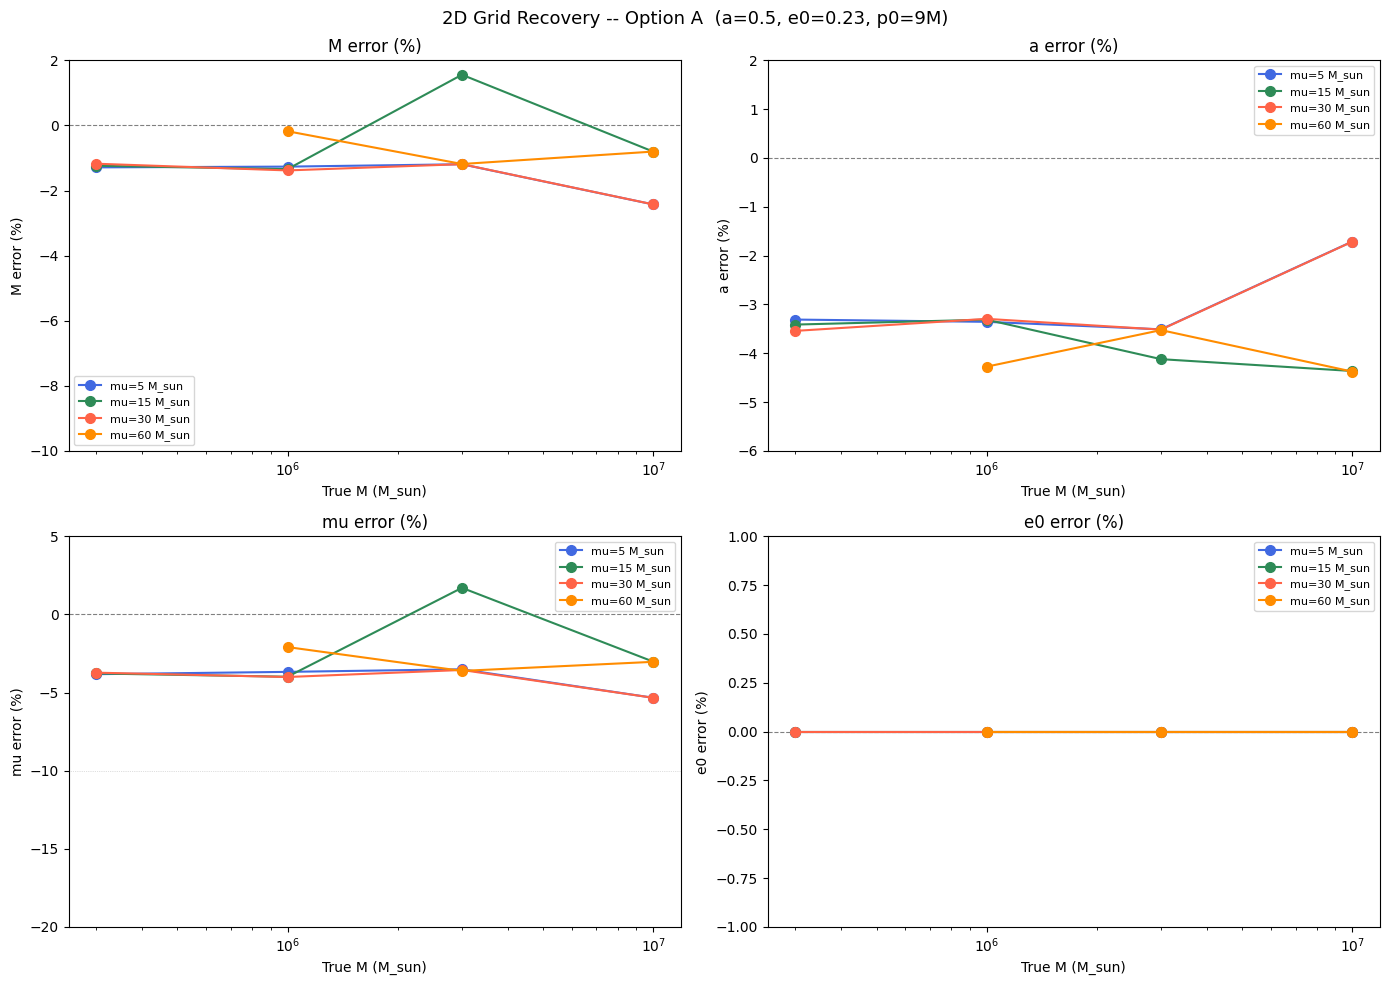

Saved: emri_2d_grid_optA.png


In [23]:
# ============================================================
# 2D MASS GRID RECOVERY TEST  --  (M, mu) x fixed p0/M
# ============================================================
# p0 = 9 M for every grid point: same orbital geometry across
# all sources, ~4.4 M above the separatrix (a=0.5, e0=0.23).
# Option A: 3x3-day fR windows, extrapolate to t=0.
#   - Corrects chirp-smearing bias in single-window fR
#   - Multi-time fR constraints break the (M,a) degeneracy
# ============================================================
import warnings
warnings.filterwarnings('ignore')

def p_from_fPhi_exact_dyn(fPhi_val_hz, a_val, e_val, x_val, M_s, p_hi=100.0):
    p_sep = get_separatrix(a_val, e_val, x_val)
    p_lo  = p_sep + 0.1
    def residual(p_try):
        try:
            Om, _, _ = get_fundamental_frequencies(a_val, p_try, e_val, x_val)
            return Om / (2*np.pi*M_s) - fPhi_val_hz
        except:
            return np.nan
    try:
        r_lo = residual(p_lo)
        r_hi = residual(p_hi)
        if np.isnan(r_lo) or np.isnan(r_hi) or r_lo*r_hi > 0:
            return np.nan
        return brentq(residual, p_lo, p_hi, xtol=1e-8)
    except:
        return np.nan


M_grid   = [3e5, 1e6, 3e6, 1e7]
mu_grid  = [5, 15, 30, 60]
P0_M     = 9.0          # fixed p0/M for all grid points
results  = []

for mu_test in mu_grid:
    for M_test in M_grid:
        print(f"\n{'='*60}")
        print(f"M = {M_test:.2e} M_sun   mu = {mu_test:.1f} M_sun   "
              f"(q = {mu_test/M_test:.2e})")
        print(f"{'='*60}")

        rec = {
            'M_true': M_test, 'mu_true': mu_test,
            'M_bl':   np.nan,  'a_bl':   np.nan,
            'mu_bl':  np.nan,  'e0_bl':  np.nan,
            'fR_err': np.nan,  'fPhi_err': np.nan,
            'status': 'failed'
        }

        try:
            # ---- Stage 0: Waveform + trajectory ----
            p0_test    = P0_M
            p_sep_test = get_separatrix(a, e0, 1.0)
            print(f"  p0 = {p0_test:.1f} M  (sep: {p_sep_test:.4f} M, "
                  f"margin: {p0_test - p_sep_test:.2f} M)")

            _stdout = sys.stdout
            sys.stdout = io.StringIO()
            h_full_t = wave_gen(
                M_test, mu_test, a, p0_test, e0, Y0,
                qS, phiS, qK, phiK, dist,
                Phi_phi0, Phi_theta0, Phi_r0,
                mich=False, dt=dt, T=T)
            t_t, p_t, e_t, x_t, _, _, _ = traj(
                M_test, mu_test, a, p0_test, e0, Y0,
                Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0,
                dt=dt, T=T, upsample=True, fix_t=True)
            sys.stdout = _stdout

            Om_phi_t, _, Om_r_t = get_fundamental_frequencies(a, p_t, e_t, x_t)
            M_s_t    = M_test * MTSUN_SI
            scale_t  = 1.0 / (M_s_t * 2*np.pi)
            fPhi_t   = Om_phi_t * scale_t
            fR_t     = Om_r_t   * scale_t
            t_days_t = t_t / 3600 / 24

            duration_days_t = len(h_full_t) * dt / 3600 / 24
            print(f"  fPhi(t=0): {fPhi_t[0]*1e3:.4f} mHz  "
                  f"fR(t=0): {fR_t[0]*1e3:.4f} mHz  "
                  f"duration: {duration_days_t:.1f} days")

            # ---- Stage 0.5: TDI ----
            h_A_t = np.real(h_full_t).astype(np.float64)
            h_E_t = np.imag(h_full_t).astype(np.float64)

            # ---- Stage 1: WDM ----
            Nt_t = 512
            Nf_t = len(h_A_t) // Nt_t
            ND_t = Nf_t * Nt_t
            if ND_t < Nt_t:
                print("  SKIP: waveform too short for WDM")
                results.append(rec)
                continue

            if duration_days_t < 15.0:
                print(f"  SKIP: duration {duration_days_t:.1f} days too short")
                results.append(rec)
                continue

            Tobs_t    = ND_t * dt
            wf_t      = np.arange(0, Nf_t+1) / (2*dt*Nf_t)
            wf_mHz_t  = wf_t * 1e3
            wt_days_t = np.linspace(0, Tobs_t, Nt_t+1) / 3600 / 24

            _stdout = sys.stdout; sys.stdout = io.StringIO()
            aa_A_t = transform_wavelet_time(h_A_t[:ND_t], Nf_t, Nt_t)
            aa_E_t = transform_wavelet_time(h_E_t[:ND_t], Nf_t, Nt_t)
            sys.stdout = _stdout

            WDM_t = np.abs(aa_A_t) + np.abs(aa_E_t)

            fPhi0_mHz_t = fPhi_t[0] * 1e3
            f_lo_t      = max(0.05, fPhi0_mHz_t * 0.3)
            f_hi_t      = min(wf_mHz_t[-2], fPhi0_mHz_t * 4.0)
            f_mask_t    = (wf_mHz_t[:-1] > f_lo_t) & (wf_mHz_t[:-1] < f_hi_t)
            WDM_band_t  = WDM_t[:, f_mask_t].T
            f_band_t    = wf_mHz_t[:-1][f_mask_t]
            t_bins_t    = wt_days_t[:-1]

            # ---- Stage 2a: Viterbi seed ----
            seed_t = 2.0 * fPhi0_mHz_t

            # ---- Stage 2b: Multi-window fR (3x3-day), extrapolate to t=0 ----
            fPhi_approx   = seed_t / 2.0
            fR_search_lo  = max(0.05, fPhi_approx * 0.3)
            fR_search_hi  = fPhi_approx * 0.95

            fR_windows_raw_t = []
            win_days_t = 3.0
            for wi in range(3):
                i_start_t = int(wi * win_days_t * 86400 / dt)
                i_end_t   = min(int((wi + 1) * win_days_t * 86400 / dt), len(h_A_t))
                n_samp_t  = i_end_t - i_start_t
                if n_samp_t < 1000:
                    break
                h_win_wi     = (h_A_t[i_start_t:i_end_t] + h_E_t[i_start_t:i_end_t]) * np.hanning(n_samp_t)
                freqs_win_wi = np.fft.rfftfreq(n_samp_t, d=dt) * 1e3
                power_win_wi = np.abs(np.fft.rfft(h_win_wi))**2
                fR_mask_wi   = (freqs_win_wi > fR_search_lo) & (freqs_win_wi < fR_search_hi)
                if fR_mask_wi.sum() < 5:
                    break
                fR_peak_wi = freqs_win_wi[fR_mask_wi][np.argmax(power_win_wi[fR_mask_wi])]
                fR_win_wi  = gaussian_peak(freqs_win_wi, power_win_wi,
                                           fR_peak_wi, f_window=0.05)
                t_mid_wi   = (wi + 0.5) * win_days_t
                fR_windows_raw_t.append((t_mid_wi, fR_win_wi * 1e-3))

            if len(fR_windows_raw_t) >= 2:
                _t_mt  = np.array([t for t, _ in fR_windows_raw_t])
                _fR_mt = np.array([f for _, f in fR_windows_raw_t])
                _ct    = np.polyfit(_t_mt, _fR_mt, 1)
                fR_hr_t_hz = float(np.polyval(_ct, 0.0))
            elif fR_windows_raw_t:
                fR_hr_t_hz = fR_windows_raw_t[0][1]
            else:
                fR_hr_t_hz = fR_t[0]

            fR_err_t      = (fR_hr_t_hz*1e3 - fR_t[0]*1e3) / (fR_t[0]*1e3) * 100
            rec['fR_err'] = fR_err_t
            print(f"  fR extrap t=0: {fR_hr_t_hz*1e3:.5f} mHz  "
                  f"(true: {fR_t[0]*1e3:.5f}, err: {fR_err_t:.4f}%)")

            # ---- Stage 3: Viterbi ----
            track_t_arr, track_time_t = viterbi_track(
                WDM_band_t, f_band_t,
                f_center=seed_t, f_window=0.6, max_jump=8)
            if track_t_arr is None:
                print("  SKIP: Viterbi failed")
                results.append(rec)
                continue

            # ---- Stage 4: fPhi(t) ----
            t_cut_t    = min(30.0, t_days_t[-1] * 0.4)
            good_t     = track_time_t < t_cut_t
            t_good_t   = track_time_t[good_t]
            fPhi_raw_t = track_t_arr[good_t] / 2.0
            if len(fPhi_raw_t) < 25:
                print("  SKIP: too few Viterbi points before cutoff")
                results.append(rec)
                continue

            wl           = min(21, len(fPhi_raw_t) // 2 * 2 - 1)
            fPhi_sm_t    = savgol_filter(fPhi_raw_t,
                                         window_length=wl, polyorder=2)
            fPhi_sm_hz_t = fPhi_sm_t * 1e-3
            fPhi_v0_hz_t = fPhi_sm_hz_t[0]

            fPhi_err_t      = (fPhi_sm_t[0] - fPhi_t[0]*1e3) / (fPhi_t[0]*1e3) * 100
            rec['fPhi_err'] = fPhi_err_t
            print(f"  fPhi0 (Viterbi): {fPhi_sm_t[0]:.5f} mHz  "
                  f"(true: {fPhi_t[0]*1e3:.5f}, err: {fPhi_err_t:.4f}%)")

            e_int_t = np.interp(t_good_t, t_days_t, e_t)
            x_int_t = np.interp(t_good_t, t_days_t, x_t)

            # Convert fR window mid-times to indices into t_good_t
            fR_multi_t = []
            for t_mid, fR_hz in fR_windows_raw_t:
                idx_t = int(np.searchsorted(t_good_t, t_mid))
                idx_t = min(idx_t, len(t_good_t) - 1)
                fR_multi_t.append((idx_t, fR_hz))
            if not fR_multi_t:
                fR_multi_t = [(0, fR_hr_t_hz)]  # fallback

            # ---- Stage 5: Blind M, a -- first pass ----
            res_bl_t = minimize(
                consistency_3freq,
                x0=[M_test*1.1, a*0.9, mu_test*1.1],
                args=(fPhi_sm_hz_t, e_int_t, x_int_t, fR_hr_t_hz),
                method='Nelder-Mead',
                options={'xatol': 1.0, 'fatol': 1e-25,
                         'maxiter': 1500, 'disp': False})
            M_bl_t, a_bl_t, _ = res_bl_t.x

            # ---- Stage 6: Blind e0 ----
            M_s_bl_t = M_bl_t * MTSUN_SI
            e_scan_t = np.linspace(0.01, 0.69, 200)
            r_scan_t = []
            for ei in e_scan_t:
                try:
                    p_try = p_from_fPhi_exact_dyn(
                        fPhi_v0_hz_t, a_bl_t, ei, 1.0, M_s_bl_t)
                    if np.isnan(p_try):
                        r_scan_t.append(1e10); continue
                    p_sep = get_separatrix(a_bl_t, ei, 1.0)
                    if p_try < p_sep + 0.1:
                        r_scan_t.append(1e10); continue
                    _, _, Om_r_ei = get_fundamental_frequencies(
                        a_bl_t, p_try, ei, 1.0)
                    r_scan_t.append(
                        Om_r_ei / (2*np.pi*M_s_bl_t) - fR_hr_t_hz)
                except:
                    r_scan_t.append(1e10)
            r_scan_t = np.array(r_scan_t)
            sc_t     = np.where(np.diff(np.sign(r_scan_t)))[0]
            if len(sc_t) > 0:
                def e_res_fine(ei):
                    try:
                        p_try = p_from_fPhi_exact_dyn(
                            fPhi_v0_hz_t, a_bl_t, ei, 1.0, M_s_bl_t)
                        if np.isnan(p_try): return 1e10
                        p_sep = get_separatrix(a_bl_t, ei, 1.0)
                        if p_try < p_sep + 0.1: return 1e10
                        _, _, Om_r = get_fundamental_frequencies(
                            a_bl_t, p_try, ei, 1.0)
                        return Om_r / (2*np.pi*M_s_bl_t) - fR_hr_t_hz
                    except:
                        return 1e10
                try:
                    e0_bl_t = brentq(e_res_fine,
                                     e_scan_t[sc_t[0]],
                                     e_scan_t[sc_t[0]+1],
                                     xtol=1e-8)
                except:
                    e0_bl_t = e_t[0]
            else:
                e0_bl_t = e_t[0]
                print("  WARNING: e0 brentq no bracket -- using true e0")

            e_bl_t     = e_t * (e0_bl_t / e_t[0])
            e_bl_int_t = np.interp(t_good_t, t_days_t, e_bl_t)

            # ---- Stage 7: Re-run M, a with blind e ----
            res_bl2_t = minimize(
                consistency_3freq,
                x0=[M_bl_t, a_bl_t, mu_test*1.1],
                args=(fPhi_sm_hz_t, e_bl_int_t,
                      np.ones_like(t_good_t), fR_hr_t_hz),
                method='Nelder-Mead',
                options={'xatol': 1.0, 'fatol': 1e-25,
                         'maxiter': 1500, 'disp': False})
            M_bl_t, a_bl_t, _ = res_bl2_t.x

            # ---- Stage 8: Blind mu -- trajectory-derived pdot ----
            M_s_bl_t    = M_bl_t * MTSUN_SI
            stride_traj = max(1, len(t_t) // 200)
            t_traj_days = t_t[::stride_traj] / 86400.0
            p_traj      = p_t[::stride_traj]
            e_bl_traj   = np.interp(t_traj_days, t_days_t, e_bl_t)
            pdot_bl_t   = robust_pdot(t_traj_days, p_traj)

            ode_bl_t = PN5()
            ode_bl_t.add_fixed_parameters(M_bl_t, 1.0, a_bl_t)
            F_bl_t = []
            for i in range(len(t_traj_days)):
                try:
                    y = np.array([p_traj[i], e_bl_traj[i], 1.0, 0., 0., 0.])
                    F_bl_t.append(ode_bl_t(y)[0])
                except:
                    F_bl_t.append(np.nan)
            F_bl_t  = np.array(F_bl_t)
            F_ok_t  = ~np.isnan(F_bl_t)
            if F_ok_t.sum() < 3:
                print("  WARNING: too few valid F points for mu recovery")
                mu_bl_t = np.nan
            else:
                mu_bl_t = np.nanmedian(
                    pdot_bl_t[F_ok_t] * M_s_bl_t / F_bl_t[F_ok_t]) * M_bl_t

            rec.update({
                'M_bl': M_bl_t, 'a_bl': a_bl_t,
                'mu_bl': mu_bl_t, 'e0_bl': e0_bl_t,
                'status': 'ok'
            })

            print(f"  M:  {M_bl_t:.3e}  (true: {M_test:.2e}, "
                  f"err: {(M_bl_t-M_test)/M_test*100:+.2f}%)")
            print(f"  a:  {a_bl_t:.5f}   (true: {a:.5f}, "
                  f"err: {(a_bl_t-a)/a*100:+.3f}%)")
            print(f"  mu: {mu_bl_t:.3f}   (true: {mu_test:.3f}, "
                  f"err: {(mu_bl_t-mu_test)/mu_test*100:+.2f}%)")
            print(f"  e0: {e0_bl_t:.5f}  (true: {e_t[0]:.5f}, "
                  f"err: {(e0_bl_t-e_t[0])/e_t[0]*100:+.4f}%)")

        except Exception as ex:
            sys.stdout = _stdout
            print(f"  FAILED: {ex}")

        results.append(rec)

# ============================================================
# SUMMARY TABLE
# ============================================================
print(f"\n{'='*75}")
print("2D GRID RECOVERY SUMMARY  (true a=0.5000, e0=0.2287, p0=9M) -- Option A")
print(f"{'='*75}")
for mu_test in mu_grid:
    print(f"\n  mu_true = {mu_test:.0f} M_sun")
    print(f"  {'M (M_sun)':>9}  {'M err%':>7}  {'a err%':>7}  "
          f"{'mu err%':>7}  {'e0 err%':>8}  status")
    print(f"  {'-'*65}")
    for r in [r for r in results if r['mu_true'] == mu_test]:
        if r['status'] == 'ok':
            print(f"  {r['M_true']:>9.1e}  "
                  f"{(r['M_bl']-r['M_true'])/r['M_true']*100:>+7.2f}  "
                  f"{(r['a_bl']-a)/a*100:>+7.3f}  "
                  f"{(r['mu_bl']-r['mu_true'])/r['mu_true']*100:>+7.2f}  "
                  f"{(r['e0_bl']-e0)/e0*100:>+8.4f}  ok")
        else:
            print(f"  {r['M_true']:>9.1e}  {'---':>7}  {'---':>7}  "
                  f"{'---':>7}  {'---':>8}  SKIP/FAIL")
print(f"\n{'='*75}")

# ============================================================
# SUMMARY PLOTS
# ============================================================
ok = [r for r in results if r['status'] == 'ok']
M_ok  = np.array([r['M_true']  for r in ok])
mu_ok = np.array([r['mu_true'] for r in ok])
M_err_ok  = np.array([(r['M_bl'] -r['M_true'])/r['M_true']*100 for r in ok])
a_err_ok  = np.array([(r['a_bl'] -a)/a*100                         for r in ok])
mu_err_ok = np.array([(r['mu_bl']-r['mu_true'])/r['mu_true']*100 for r in ok])
e0_err_ok = np.array([(r['e0_bl']-e0)/e0*100                       for r in ok])

colors_mu = {5: 'royalblue', 15: 'seagreen', 30: 'tomato', 60: 'darkorange'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('2D Grid Recovery -- Option A  (a=0.5, e0=0.23, p0=9M)', fontsize=13)

pairs = [
    (axes[0,0], M_err_ok,  'M error (%)',   (-10, 2)),
    (axes[0,1], a_err_ok,  'a error (%)',   (-6,  2)),
    (axes[1,0], mu_err_ok, 'mu error (%)',  (-20, 5)),
    (axes[1,1], e0_err_ok, 'e0 error (%)',  (-1,  1)),
]

for ax, err_ok, label, ylim in pairs:
    ax.axhline(0,   color='gray', lw=0.8, linestyle='--')
    ax.axhline(10,  color='gray', lw=0.5, linestyle=':', alpha=0.5)
    ax.axhline(-10, color='gray', lw=0.5, linestyle=':', alpha=0.5)
    for mu_val in mu_grid:
        mask = mu_ok == mu_val
        if mask.sum() > 0:
            ax.plot(M_ok[mask], err_ok[mask], 'o-',
                    color=colors_mu[mu_val], lw=1.5, ms=7,
                    label=f'mu={mu_val} M_sun')
    ax.set_xscale('log')
    ax.set_xlabel('True M (M_sun)')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.set_ylim(ylim)

plt.tight_layout()
plt.savefig('emri_2d_grid_optA.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: emri_2d_grid_optA.png")


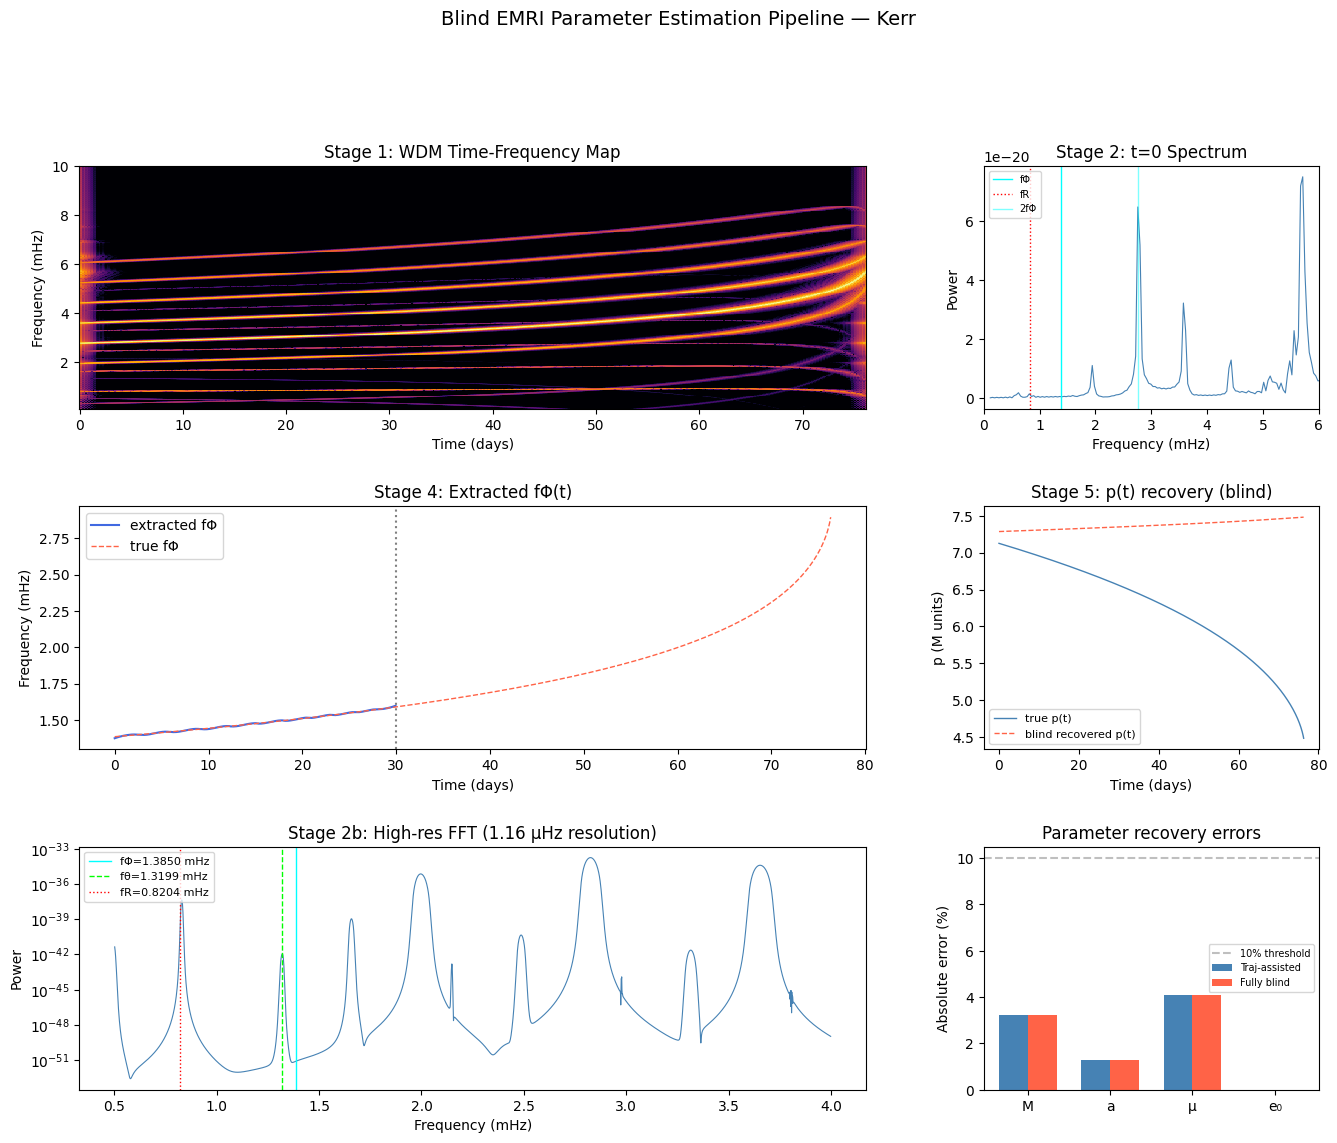

Summary figure saved as emri_pipeline_summary.png


In [43]:
# ============================================================
# SUMMARY PLOTS
# ============================================================
fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.35)
# --- Plot 1: WDM power map ---
ax1 = fig.add_subplot(gs[0, :2])
ax1.pcolormesh(t_bins, f_band,
               np.log10(WDM_band + 1e-30),
               shading='auto', cmap='inferno',
               vmin=np.log10(WDM_band.max()*1e-6),
               vmax=np.log10(WDM_band.max()))
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Frequency (mHz)')
ax1.set_title('Stage 1: WDM Time-Frequency Map')
# --- Plot 2: t=0 power spectrum ---
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(f_band, WDM_band[:, 0], 'steelblue', lw=0.8)
ax2.axvline(fPhi[0]*1e3,   color='cyan', lw=1, label='fΦ')
ax2.axvline(fR[0]*1e3,     color='red',  lw=1, linestyle=':', label='fR')
ax2.axvline(2*fPhi[0]*1e3, color='cyan', lw=1, alpha=0.5, label='2fΦ')
ax2.set_xlabel('Frequency (mHz)')
ax2.set_ylabel('Power')
ax2.set_title('Stage 2: t=0 Spectrum')
ax2.set_xlim(0, 6)
ax2.legend(fontsize=7)
# --- Plot 3: Extracted fΦ(t) ---
ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(t_good, fPhi_smooth, 'royalblue', lw=1.5, label='extracted fΦ')
ax3.plot(t_days_traj, fPhi*1e3, 'tomato', lw=1.0,
         linestyle='--', label='true fΦ')
ax3.axvline(t_cutoff, color='gray', linestyle=':')
ax3.set_xlabel('Time (days)')
ax3.set_ylabel('Frequency (mHz)')
ax3.set_title('Stage 4: Extracted fΦ(t)')
ax3.legend()
# --- Plot 4: p(t) recovery ---
ax4 = fig.add_subplot(gs[1, 2])
t_sub2      = t_days_traj[::100]
e_blind_sub = e_blind[::100]
p_check     = np.array([
    p_from_fPhi_exact(fPhi[j], a_bl, e_blind_sub[j], 1.0, M_bl*MTSUN_SI)
    for j in range(len(t_sub2))])
ax4.plot(t_days_traj, p, 'steelblue', lw=1.0, label='true p(t)')
ax4.plot(t_sub2, p_check, 'tomato', lw=1.0,
         linestyle='--', label='blind recovered p(t)')
ax4.set_xlabel('Time (days)')
ax4.set_ylabel('p (M units)')
ax4.set_title('Stage 5: p(t) recovery (blind)')
ax4.legend(fontsize=8)
# --- Plot 5: High-res FFT ---
ax5 = fig.add_subplot(gs[2, :2])
mask_plot = (freqs_hr > 0.5) & (freqs_hr < 4.0)
ax5.semilogy(freqs_hr[mask_plot], power_hr[mask_plot],
             'steelblue', lw=0.8)
ax5.axvline(fPhi[0]*1e3,   color='cyan', lw=1,
            label=f'fΦ={fPhi[0]*1e3:.4f} mHz')
ax5.axvline(fTheta[0]*1e3, color='lime', lw=1, linestyle='--',
            label=f'fθ={fTheta[0]*1e3:.4f} mHz')
ax5.axvline(fR[0]*1e3,     color='red',  lw=1, linestyle=':',
            label=f'fR={fR[0]*1e3:.4f} mHz')
ax5.set_xlabel('Frequency (mHz)')
ax5.set_ylabel('Power')
ax5.set_title(f'Stage 2b: High-res FFT ({fft_freq_res*1e3:.2f} μHz resolution)')
ax5.legend(fontsize=8)
# --- Plot 6: Parameter recovery bar chart ---
ax6 = fig.add_subplot(gs[2, 2])
params_names = ['M', 'a', 'μ', 'e₀']
errors_traj  = [abs((M_ta-M)/M*100), abs((a_ta-a)/a*100),
                abs((mu_ta-m)/m*100), 0.0]
errors_blind = [abs((M_bl-M)/M*100),  abs((a_bl-a)/a*100),
                abs((mu_bl-m)/m*100),  abs((e0_blind-e[0])/e[0]*100)]
x_pos = np.arange(len(params_names))
w     = 0.35
ax6.bar(x_pos - w/2, errors_traj,  w, label='Traj-assisted', color='steelblue')
ax6.bar(x_pos + w/2, errors_blind, w, label='Fully blind',   color='tomato')
ax6.axhline(10, color='gray', linestyle='--', alpha=0.5, label='10% threshold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(params_names)
ax6.set_ylabel('Absolute error (%)')
ax6.set_title('Parameter recovery errors')
ax6.legend(fontsize=7)
plt.suptitle('Blind EMRI Parameter Estimation Pipeline — Kerr',
             fontsize=14, y=1.01)
plt.savefig('emri_pipeline_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary figure saved as emri_pipeline_summary.png")

In [14]:
print(f"p0 = {p0:.4f} M")
print(f"p0/M = {p0:.4f}")  # p0 is already in M units
print(f"separatrix = {get_separatrix(a, e0, 1.0):.4f} M")

p0 = 7.1272 M
p0/M = 7.1272
separatrix = 4.5694 M


In [34]:
from numpy.polynomial import polynomial as P

# Use the already-extracted Viterbi track from block 1
# Convert fΦ(t) → p(t) at sparse points
stride   = 5   # every 5th Viterbi time bin
t_sp     = t_good[::stride]
fPhi_sp  = fPhi_smooth_hz[::stride]
e_sp     = np.interp(t_sp, t_days_traj, e)
x_sp     = np.interp(t_sp, t_days_traj, x)

M_s_ta = M_ta * MTSUN_SI
p_sp = np.array([
    p_from_fPhi_exact(fPhi_sp[i], a_ta, e_sp[i], x_sp[i], M_s_ta)
    for i in range(len(t_sp))
])
valid_sp = ~np.isnan(p_sp)
t_v   = t_sp[valid_sp]
p_v   = p_sp[valid_sp]

# Normalize time to [0,1] for numerical stability
T_span = t_v[-1] - t_v[0]
tau    = (t_v - t_v[0]) / T_span

# Fit polynomials of increasing degree and pick best
for deg in [2, 3, 4]:
    coeffs  = np.polyfit(tau, p_v, deg)
    p_fit   = np.polyval(coeffs, tau)
    resid   = np.std(p_v - p_fit)
    # Analytical derivative dp/dtau, convert to dp/dt
    dcoeffs = np.polyder(coeffs)
    pdot_fit = np.polyval(dcoeffs, tau) / (T_span * 86400)  # M/s

    # PN5 flux at each point
    ode_poly = PN5()
    ode_poly.add_fixed_parameters(M_ta, 1.0, a_ta)
    F_poly = []
    for i in range(len(t_v)):
        try:
            y = np.array([p_v[i], e_sp[valid_sp][i],
                          x_sp[valid_sp][i], 0., 0., 0.])
            F_poly.append(ode_poly(y)[0])
        except:
            F_poly.append(np.nan)
    F_poly  = np.array(F_poly)
    F_ok    = ~np.isnan(F_poly)
    mu_poly = np.nanmedian(
        pdot_fit[F_ok] * M_s_ta / F_poly[F_ok]) * M_ta

    print(f"deg={deg}: fit resid={resid:.2e}  "
          f"mu={mu_poly:.4f}  err={( mu_poly-m)/m*100:+.3f}%")

deg=2: fit resid=1.13e-02  mu=30.7008  err=+4.106%
deg=3: fit resid=1.09e-02  mu=30.8771  err=+4.704%
deg=4: fit resid=1.09e-02  mu=31.1136  err=+5.506%
